In [128]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
#create dataset
#AR(1) 
def ar_1(n,mu,sigma,phi,seed):
    #y = []
    rng = np.random.default_rng(seed=seed)
    y = np.zeros(n)
    epslon = rng.normal(mu,sigma,n)
    for t in range(1,n):
        y[t] =(phi*y[t-1]) + epslon[t]
    return y


In [ ]:
#create dataset 
#ARMA(1,1)
def arma_11(n,mu,sigma,phiY,phiE,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = (phiY*y[t-1]) + epslon[t] + (phiE*epslon[t-1])     
    return y


In [ ]:
#create dataset
#Mean shift
def mean_shift(n,mu,sigma,shift_mean,phi,seed):
    rng = np.random.default_rng(seed=seed)
    epslon = rng.normal(mu,sigma,n)
    y = epslon.copy()
    y[shift_mean:] += 1.0  
    for t in range(1, n):
        y[t] = (phi*y[t-1]) + ((1-phi)*y[t])
    return y


In [ ]:
#create dataset 
#GARCH(1,1)
def garch(n,mu,sigma,a,phi,b,seed):
    rng = np.random.default_rng(seed=seed)
    epsol = rng.normal(mu,sigma,n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = epsol[t]*(np.sqrt(a+(phi*(y[t-1]**2))+b))

    return y


In [ ]:
#convert time-series into x,y
# lag = 3
def dataset(lag,y):
    x  = []
    y_target = []
    full_dataset = []
    for t in range(lag,len(y)):
        x.append(y[t-lag:t])
        y_target.append(y[t])
    #full_dataset = x,y_target
    #print(f'len x:{len(x)} len y:{len(y_target)}')
    return x,y_target 


### fine tuning for finding the best lr 

In [135]:
# fit model 
def fit_linear_regression(X_train,y_train,X_val,y_val,learning_rate,epochs):

    results ={}
    di = {}

    for lr in learning_rate:
        beta_0 = 0.0
        beta_1 = 0.0
        beta_2 = 0.0
        beta_3 = 0.0
        best_val_mse = np.inf
        best_beta = None
        diverged = False
        for epoch in range(epochs):

            #compute prediction using linear regression
            y_hat_train = (beta_0 + (beta_1*X_train[:,0]) + (beta_2*X_train[:,1]) + (beta_3*X_train[:,2]))

            #compute train error
            error_train = y_train - y_hat_train
            # #compute MSE train
            # mse_train = np.mean(error_train*error_train)

            #compute prediction using linear regression
            y_hat_val = (beta_0 + (beta_1*X_val[:,0]) + (beta_2*X_val[:,1]) + (beta_3*X_val[:,2]))

            #compute val error
            error_val = y_val - y_hat_val

            if (
                not np.all(np.isfinite(error_train)) 
                or not np.all(np.isfinite(error_val)) 
                or np.max(np.abs(error_train)) > 1e100
                or np.max(np.abs(error_val)) > 1e100
                ):
                diverged = True
                break


            #compute MSE train
            mse_train = np.mean(error_train*error_train)
            #compute MSE val
            mse_val = np.mean(error_val*error_val)


            #check if new mse_val is less than previous one
            if mse_val<best_val_mse:
                best_val_mse = mse_val
                #bests_mse.append(best_mse)
                #best_betas.append((beta_0,beta_1,beta_2,beta_3))
                best_beta = beta_0,beta_1,beta_2,beta_3
                #di[best_val_mse] = best_beta

            #derivative of the betas
            grad_b0 = -2 * np.mean(error_train)
            grad_b1 = -2 * np.mean(error_train*X_train[:,0])
            grad_b2 = -2 * np.mean(error_train*X_train[:,1])
            grad_b3 = -2 * np.mean(error_train*X_train[:,2])

            #update the betas
            beta_0 = beta_0 - (lr * grad_b0)
            beta_1 = beta_1 - (lr * grad_b1) 
            beta_2 = beta_2 - (lr * grad_b2)
            beta_3 = beta_3 - (lr * grad_b3) 

        #if this lr exploded, discarde it completely
        if diverged:
            continue

        results[lr] = {'val_mse': best_val_mse, 'betas': best_beta}

        #print(f'lr: {lr}, mse_train: {mse_train}, mse_val: {best_val_mse}, best_betas: {best_beta}')
    #find the best learning rate
    best_lr = min(results, key=lambda lr: results[lr]['val_mse'])

    #find the best_val_mse and best_beta
    best_val_mse = results[best_lr]['val_mse']
    best_beta = results[best_lr]['betas']

    # print("Best learning rate:", best_lr)
    # print("Best validation MSE:", best_val_mse)
    # print("Best betas:", best_beta)
    
    #print(f'di: {di}')
    return best_val_mse, best_beta ,best_lr




### Forecasting Model

In [138]:
# fit model 
def fit_final_model(X_train,y_train,best_lr,epochs):

    #for lr in learning_rate:
    beta_0 = 0.0
    beta_1 = 0.0
    beta_2 = 0.0
    beta_3 = 0.0
    best_train_mse = np.inf
    best_beta = None
    for epoch in range(epochs):

        #compute prediction using linear regression
        y_hat_train = (beta_0 + (beta_1*X_train[:,0]) + (beta_2*X_train[:,1]) + (beta_3*X_train[:,2]))

        #compute train error
        error_train = y_train - y_hat_train
        #compute MSE train
        mse_train = np.mean(error_train*error_train)

        #check if new mse_val is less than previous one
        if mse_train<best_train_mse:
            best_train_mse = mse_train
            best_beta = beta_0,beta_1,beta_2,beta_3
        

        #derivative of the betas
        grad_b0 = -2 * np.mean(error_train)
        grad_b1 = -2 * np.mean(error_train*X_train[:,0])
        grad_b2 = -2 * np.mean(error_train*X_train[:,1])
        grad_b3 = -2 * np.mean(error_train*X_train[:,2])

        #update the betas
        beta_0 = beta_0 - (best_lr * grad_b0)
        beta_1 = beta_1 - (best_lr * grad_b1) 
        beta_2 = beta_2 - (best_lr * grad_b2)
        beta_3 = beta_3 - (best_lr * grad_b3) 

    return best_beta

In [140]:
# compute thre prediction using linear regression
def prediction_linear(x_cal,beta_0,beta_1,beta_2,beta_3):
    y_hat = (beta_0 + (beta_1*x_cal[:,0]) + (beta_2*x_cal[:,1]) + (beta_3*x_cal[:,2])) 
    return y_hat

# y_hat_cal =  prediction_linear(X_cal, beta_0,beta_1,beta_2,beta_3)

### fine tune for finding the best rho

In [ ]:
# tune fine rho using Weighted Conformal Predition
def wcp(X_train_tuning, y_train_tuning, X_cal_tuning, y_cal_tuning, X_val, y_val, lr, rhos, alpha):
    #fit model 
    beta_0,beta_1,beta_2,beta_3 = fit_final_model(X_train_tuning,y_train_tuning,lr,epochs=10000)

    #compute residual
    y_hat_cal = prediction_linear(X_cal_tuning, beta_0,beta_1,beta_2,beta_3)
    residual_cal = np.abs(y_cal_tuning - y_hat_cal)

    coverage_list = []
    quantile_list = []
    final_rho = 0.0
    #tune fine rho
    for rho in rhos:
        w = np.zeros(len(y_cal_tuning))
        w_norm = np.zeros(len(y_cal_tuning))
        m = len(y_cal_tuning) - 1 #fixed

        #calc weight
        for i in range(len(y_cal_tuning)):
            w[i] = rho**(m - i)

        #norm weight
        for i in range(len(w)): #fixed
            w_norm[i] = w[i] / np.sum(w) 

        #compute quantile
        order = np.argsort(residual_cal) #fixed
        residual_sorted = residual_cal[order]
        weights_sorted = w_norm[order]

        counter = 0
        cum_weight =0.0 #fixed
        for i in weights_sorted: 
            cum_weight += i
            if cum_weight >= (1-alpha):
                quantile = residual_sorted[counter]
                break
            else:
                counter+=1

        #save quantile for each rhos
        quantile_list.append(quantile)
        #compute prediction on X validation 
        y_hat_val = prediction_linear(X_val,beta_0,beta_1,beta_2,beta_3)

        #compute coverage
        lower = y_hat_val - quantile
        upper = y_hat_val + quantile
        coverage = (y_val>=lower) & (y_val<=upper)
        coverage_val = np.sum(coverage) / len(y_val)
        test_cove = np.mean(coverage)
        coverage_list.append(coverage_val)

    # select coverage >= 0.90
    for i in range(len(coverage_list)):
        if coverage_list[i] >= (1-alpha):
            final_rho = rhos[i]
            break
        else:
            best_index = np.argmax(coverage_list)
            final_rho = rhos[best_index] 

    # print("quantile:", quantile)
    # print("min lower:", np.min(lower))
    # print("max upper:", np.max(upper))
    # print("y_val min/max:", np.min(y_val), np.max(y_val))
    # print("inside:", np.sum(coverage), "/", len(y_val))
    # print("coverage:", coverage_val)
    # #print(f'coverage_list: {coverage_list}')
    # #print(f'quantile list: {quantile_list}')
    # print(f"final_rho: {final_rho}")

    return coverage_list, quantile_list, final_rho
    

## Weighted Comnformal Predictor 

In [ ]:
# Weighted Conformal Predition
def final_wcp(X_train, y_train, X_cal, y_cal, X_test, y_test, lr, rho, alpha):

    #record starting running time
    #start = time.time()

    #fit model 
    beta_0,beta_1,beta_2,beta_3 = fit_final_model(X_train,y_train,lr,epochs=10000)

    #compute residual
    y_hat_cal = prediction_linear(X_cal, beta_0,beta_1,beta_2,beta_3)
    residual_cal = np.abs(y_cal - y_hat_cal)

    coverage_list = []
    quantile_list = []
    #tune fine rho
    #for rho in rhos:
    w = np.zeros(len(y_cal))
    w_norm = np.zeros(len(y_cal))
    m = len(y_cal) - 1 #fixed

    #calc weight
    for i in range(len(y_cal)):
        w[i] = rho**(m - i)

    #norm weight
    for i in range(len(w)): #fixed
        w_norm[i] = w[i] / np.sum(w) 

    #compute quantile
    order = np.argsort(residual_cal) #fixed
    residual_sorted = residual_cal[order]
    weights_sorted = w_norm[order]

    counter = 0
    cum_weight =0.0 #fixed
    for i in weights_sorted: 
        cum_weight += i
        if cum_weight >= (1-alpha):
            quantile = residual_sorted[counter]
            break
        else:
            counter+=1

    #save quantile for each rhos
    quantile_list.append(quantile)

    #compute coverage
    y_hat_test = prediction_linear(X_test, beta_0,beta_1,beta_2,beta_3)
    lower = y_hat_test - quantile
    upper = y_hat_test + quantile
    coverage = (y_test>=lower) & (y_test<=upper)
    coverage_test = np.sum(coverage) / len(y_test)
    test_cove = np.mean(coverage)
    coverage_list.append(coverage_test)

    #compute width
    #tot_lower = len(lower)
    #tot_upper = len(upper)
    width = (np.sum(upper - lower))/len(lower)

    # print("quantile:", quantile)
    # #print("lower:", lower)
    # #print("upper:", upper)
    # print("y_cal min/max:", np.min(y_cal), np.max(y_cal))
    # print("inside:", np.sum(coverage), "/", len(y_cal))
    # print("coverage:", coverage_test)
    # print(f'width: {width}')
    #print("tot_upper-tot_lower:", tot_upper == tot_upper)

    #record end running time
    #end = time.time()
    #print(f'total running time: {end - start}')
    return coverage_list, quantile_list, coverage_test, width 
    

In [152]:
def run_wcp_series(series, learning_rates, alpha=0.1):

    x, y = dataset(3, series)
    x = np.array(x)
    y = np.array(y)

    # tuning split
    X_train_tuning = x[:200]
    y_train_tuning = y[:200]

    X_cal_tuning = x[200:400]
    y_cal_tuning = y[200:400]

    X_val = x[400:600]
    y_val = y[400:600]

    # final split
    X_train = x[:300]
    y_train = y[:300]

    X_cal = x[300:600]
    y_cal = y[300:600]

    X_test = x[600:900]
    y_test = y[600:900]

    # tune learning rate
    _, _, lr = fit_linear_regression(
        X_train_tuning,
        y_train_tuning,
        X_val,
        y_val,
        learning_rate=learning_rates,
        epochs=10000
    )

    # tune rho
    _, _, final_rho = wcp(
        X_train_tuning,
        y_train_tuning,
        X_cal_tuning,
        y_cal_tuning,
        X_val,
        y_val,
        lr,
        rhos=[
            .80,.81,.82,.83,.84,.85,.86,.87,.88,.89,
            .90,.91,.92,.93,.94,.95,.96,.97,.98,.99
        ],
        alpha=alpha
    )

    #running time 
    start_time = time.time()
    # final WCP
    _, _, coverage, width = final_wcp(
        X_train,
        y_train,
        X_cal,
        y_cal,
        X_test,
        y_test,
        lr,
        final_rho,
        alpha
    )
    end_time = time.time()
    running_time = end_time - start_time

    return coverage, width,running_time

In [153]:
def confInterval_WCP(wcp_di, n_rep):

    names = ['ar', 'arma', 'ms', 'ga']

    coverages = {name: [] for name in names}
    widths = {name: [] for name in names}
    timer = {name: [] for name in names}
    mean_times = {}

    lr_grids = {
        'ar': [
            0.0000001,0.00001,0.0001,0.001,
            0.01,0.02,0.03,0.04,0.05,0.06,
            0.07,0.08,0.09,0.1,
            0.101,0.102,0.103,0.104,0.105,
            0.106,0.107,0.108,0.109
        ],

        'arma': [
            0.0000001,0.00001,0.0001,0.001,
            0.002,0.003,0.004,0.005,0.006,
            0.007,0.008,0.009,0.01,0.1
        ],

        'ms': [
            0.0000001,0.00001,0.0001,0.001,
            0.01,0.1,0.11,0.12,0.13,0.14,0.15
        ],

        'ga': [
            0.0000001,0.00001,0.0001,
            0.001,0.01,0.1
        ]
    }

    for seed in range(n_rep):

        series = {
            'ar': ar_1(
                n=903, mu=0, sigma=1.0,
                phi=0.8, seed=seed
            ),

            'arma': arma_11(
                n=903, mu=0, sigma=1.0,
                phiY=0.5, phiE=0.4, seed=seed
            ),

            'ms': mean_shift(
                n=903, mu=0, sigma=1.0,
                shift_mean=600, phi=0.3, seed=seed
            ),

            'ga': garch(
                n=903, mu=0, sigma=1.0,
                a=0.3, phi=0.5, b=0.1, seed=seed
            )
        }

        for name in names:
            #print("seed:", seed, "model:", name)

            coverage, width,running_time = run_wcp_series(
                series[name],
                lr_grids[name],
                alpha=0.1
            )

            coverages[name].append(coverage)
            widths[name].append(width)
            timer[name].append(running_time)

    #centre points
    for name in names:

        cov = np.array(coverages[name])
        wid = np.array(widths[name])
        ti = np.array(timer[name])
        mean_coverage = np.mean(cov)
        mean_width = np.mean(wid)
        mean_time = np.mean(ti)
        mean_times[name] = mean_time


        #confidence interval coverage level 95%
        std_coverage = np.sqrt(np.sum((cov-mean_coverage)**2)/(len(cov)-1))
        coverage_err =1.96*std_coverage/np.sqrt(len(cov))  
        #test_cove = 1.96*np.std(coverage,ddof=1)/np.sqrt(len(coverage))
        #coverage interval width level 95%
        std_width = np.sqrt(np.sum((wid-mean_width)**2)/(len(cov)-1))
        width_err =1.96*std_width/np.sqrt(len(wid))  

        wcp_di[name] = (
            mean_coverage,
            mean_width,
            coverage_err,
            width_err
        )
    #print(timer)
    return wcp_di,mean_times


In [154]:
wcp_di = {}

wcp_di,mean_times = confInterval_WCP(
    wcp_di,
    n_rep=50
)

In [155]:
wcp_di

{'ar': (np.float64(0.8814),
  np.float64(3.352728100996408),
  np.float64(0.024204909107222214),
  np.float64(0.19571493801373632)),
 'arma': (np.float64(0.8814666666666667),
  np.float64(3.367434635186247),
  np.float64(0.024289027646243886),
  np.float64(0.20627141267556717)),
 'ms': (np.float64(0.7659333333333334),
  np.float64(2.6543053433419983),
  np.float64(0.03788335040914705),
  np.float64(0.21862969554441986)),
 'ga': (np.float64(0.8603333333333335),
  np.float64(2.7100362729222063),
  np.float64(0.027205505978671954),
  np.float64(0.22371664649049))}

In [156]:
mean_times

{'ar': np.float64(0.4536235618591309),
 'arma': np.float64(0.45204939842224123),
 'ms': np.float64(0.4470875453948975),
 'ga': np.float64(0.45253788471221923)}

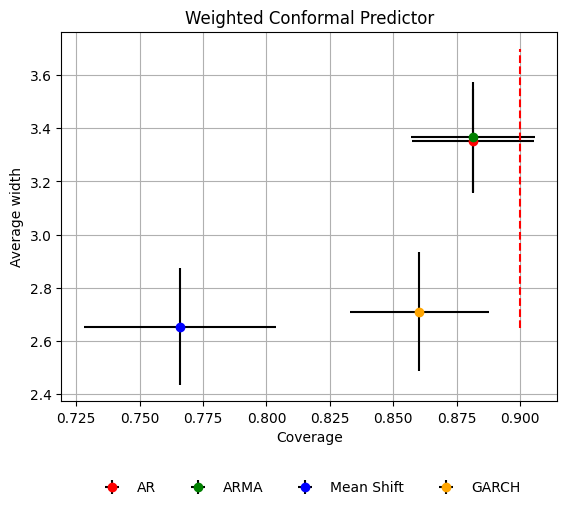

In [157]:
# import matplotlib.pyplot as plt
# import numpy as np



#x = [1, 2, 3, 4]
#y = [10, 15, 7, 12]
#yerr = [1.5, 2.0, 1.0, 1.8]
#xerr  = [1.5, 2.0, 1.0, 1.8]
mean_coverage, mean_width, coverage_err, width_err = wcp_di['ar']
colors = ['red', 'green', 'blue', 'orange']
labels = ['AR', 'ARMA', 'Mean Shift', 'GARCH']
#colors = ['red']
for model, col,lab in zip(['ar','arma','ms','ga'],colors,labels):
    mean_coverage, mean_width, coverage_err, width_err = wcp_di[model]
    plt.errorbar(mean_coverage, mean_width, xerr=coverage_err, yerr=width_err, fmt='o', ecolor='black', color=col,label=lab)
plt.vlines(x=0.90,ymin=2.65,ymax=3.7,colors='r',linestyles='--')
plt.title("Weighted Conformal Predictor")
plt.xlabel('Coverage')
plt.ylabel('Average width')
# LEGENDA SOTTO "Coverage"
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    frameon=False
)
plt.grid()
plt.show()

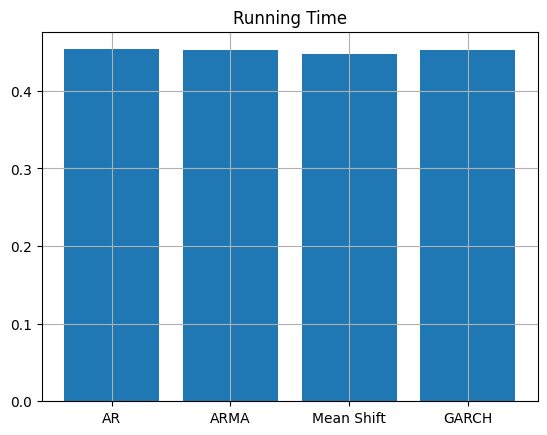

In [158]:
x = ['AR','ARMA','Mean Shift','GARCH']
y = [mean_times['ar'],mean_times['arma'],mean_times['ms'],mean_times['ga']]
plt.bar(x,y)
plt.title('Running Time')
plt.grid()
plt.show()